In [ ]:
from pipeline_functions import *
import torch
import snntorch.spikeplot as splt
import matplotlib.pyplot as plt
import numpy as np
import mat73

In [ ]:
file_path = f"C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/datasets/Won2022_BIDS/.mat_files/s01.mat"

In [ ]:

# create module
snn = SNNModule.createSNN(8, [128, 64], betas=[0.95, 0.95, 0.95], thresholds=[1, 1, 1], p=0.2)

# load in weights
# weights_path = "C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/12864_th09_f3_stdf1/checkpoint_e70.tar"
# weights = torch.load(weights_path, map_location=torch.device('cpu'))['model_state_dict']
#weights_path = 'C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/noavgf3_th08_weights.pth'
# weights_path = 'C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/snn_weights_2_window937_fs10_spkreg.pth'
# weights_path = 'C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/2hl12864_th072_win2_4_f3_weights.pth'
weights_path = 'C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/12864_th09_f3_stdf1_weights.pth'
weights = torch.load(weights_path, weights_only=True)
snn.load_state_dict(weights)

snn.eval()

fcSNN(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (lif2): Leaky()
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (lif3): Leaky()
  (dp): Dropout(p=0.2, inplace=False)
)

## Training Character Accuracy

4
Raw data shape: (32, 161920)
(8, 307, 1260)
Raw data shape: (32, 117120)
Subject 1 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 2 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 3 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 4 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 5 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 6 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 7 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 8 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 9 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 10 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 11 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 12 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 13 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 14 loaded. Size: (8, 307, 180

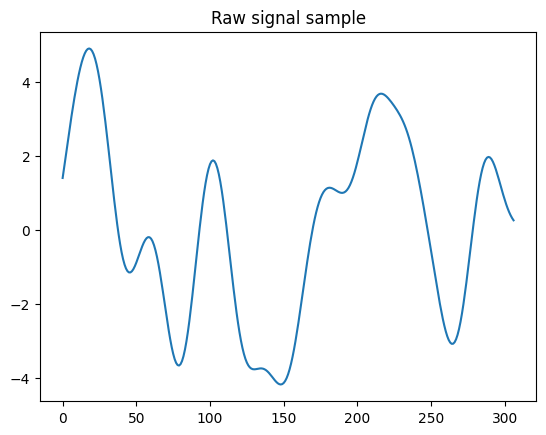

In [ ]:
data = mat73.loadmat(file_path)
t1 = data["test"]

X = np.empty((8, 307, 99000), dtype=np.float32) # 99000 for training, 69,300 for val
y = np.empty((99000,), dtype=np.float32)
chars = ''  # Initialize chars as an empty list to store character labels

# loads data for all 55 subjects and preprocesses it
x_idx, y_idx = 0, 0
for num_subj in range(55): 
    file_name = f"C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/datasets/Won2022_BIDS/.mat_files/s{num_subj+1:02d}.mat"
    # print(f"Loading {file_name}")
    X_subj, y_subj, char_subj= fn_preprocess.preprocess_testing(file_name, use_training=True, set=[0, 2])

    epoch_num = X_subj.shape[2]
    y_len = y_subj.shape[0]
    
    X[:, :, x_idx:x_idx+epoch_num] = X_subj.astype(np.float32, copy=False)
    y[y_idx:y_idx+y_len] = y_subj.astype(np.float32, copy=False)
    chars += char_subj  # Append character labels to the chars list

    x_idx += epoch_num
    y_idx += y_len

    print(f"Subject {num_subj+1} loaded. Size: {X_subj.shape}")

print(f"Total data shape: {X.shape}, Total labels shape: {y.shape}, Total chars length: {len(chars)}")

plt.plot(X[0, :, 0])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()


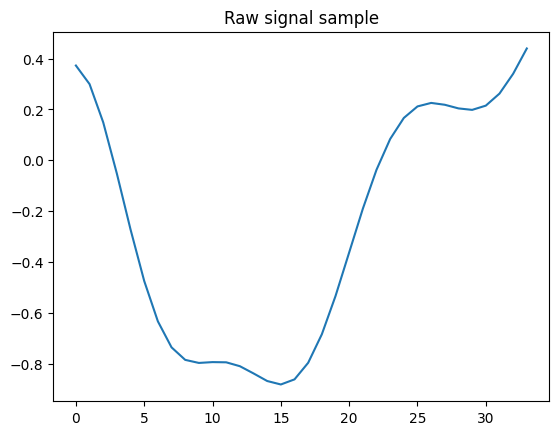

In [ ]:

# feature extraction
X_fe, y_fe = fn_feature_extraction.extractFeatures(X, y, factor=3, t_min=200, t_max=400, norm_factor=1, norm_type='std')

plt.plot(X_fe[0, 0, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()



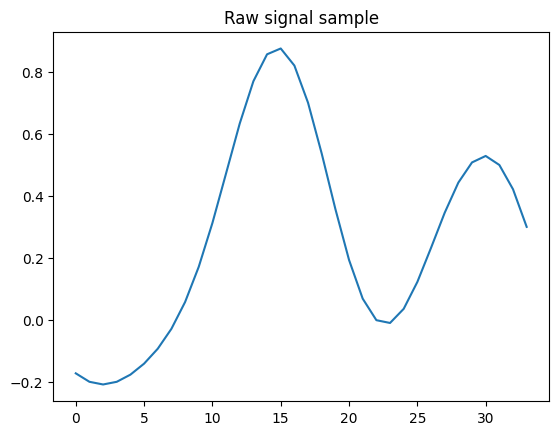

(99000, 34, 8)
[[ 1  0  1  1  1  1  1 -1]
 [ 0  0 -1  0  1  0  0  0]
 [-1  0 -1  0  1  0  0  0]
 [-1 -1  0  0  0 -1  0  0]
 [-1 -1  0  0  0 -1 -1  0]
 [-1 -1  0 -1 -1 -1 -1  0]
 [-1 -1  0 -1 -1 -1 -1  0]
 [-1 -1  0 -1 -1  0 -1  0]
 [ 0 -1  0 -1 -1  0 -1  0]
 [ 0 -1  0 -1 -1  0 -1  1]
 [ 0  0  0  0 -1  0  0  1]
 [ 0  0  0  0 -1  1  0  1]
 [ 0  1  0  1  0  1  1  1]
 [ 0  1  0  1  0  1  1  1]
 [ 0  1  0  1  1  1  1  0]
 [ 0  1  0  1  1  0  1  0]
 [ 0  1  0  1  1  0  1  0]
 [ 0  1 -1  0  1 -1  0 -1]
 [ 1  1 -1  0  1 -1  0 -1]
 [ 1  1 -1 -1  0 -1  0 -1]
 [ 1  0 -1 -1  0 -1 -1 -1]
 [ 1  0 -1 -1  0 -1 -1 -1]
 [ 1  0 -1 -1  0 -1  0  0]
 [ 1 -1 -1 -1  0  0  0  0]
 [ 0 -1  0 -1  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  1]
 [ 0  0  0  0  0  0  1  1]
 [ 0  0 -1  0  0  0  1  1]
 [ 0  0 -1  0  0  0  1  0]
 [ 0  0 -1  0  0  0  0  0]
 [ 0  0 -1  0  0 -1  0  0]
 [ 0  0 -1  0  0 -1  0  0]
 [ 1  1 -1  0 -1 -1  0 -1]]


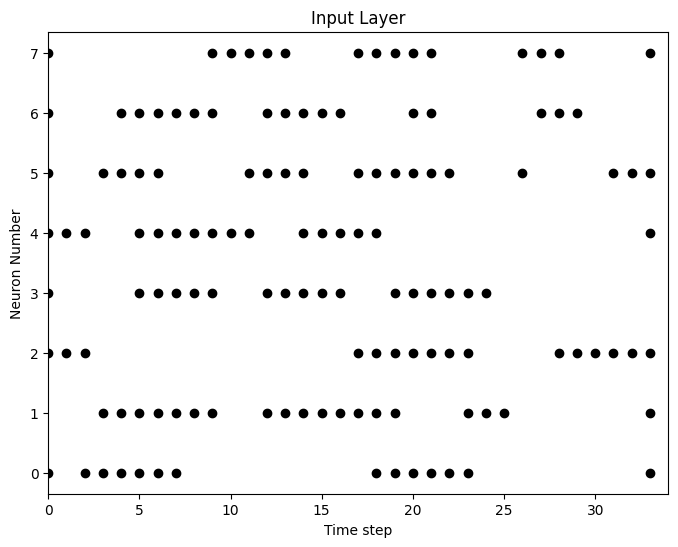

In [ ]:
plt.plot(X_fe[0, 7, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

X_encoded = delta_encoding.delta_encode(X_fe, threshold=0.09) #spike encoding to implement
print(X_encoded.shape)
# Create fig, ax
fig = plt.figure(facecolor="w", figsize=(8, 6))
ax = fig.add_subplot(111)

print(X_encoded[0, :, :])
trial_spikes = torch.from_numpy(X_encoded[0, :, :])

# Raster plot of delta converted data
splt.raster(trial_spikes, ax, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.xlim(0, X_encoded.shape[1])
plt.show()


In [ ]:

# temp = torch.from_numpy(X_encoded[0, :, :]).float().unsqueeze(0)
# spk_results, _ = snn(temp, batch_first=True)
# print(spk_results)

total_letters = 0
total_correct = 0
# separate X into individual character signals instead of one big dataset
count = 1
subj_correct = 0

num_repititions = 15//1 

num_chars_per_subj = len(chars) // 55

for i in range(len(X_encoded)//12//num_repititions):
    start_idx = i*12*(num_repititions)
    end_idx = start_idx + 12*(num_repititions)
    X_char = X_encoded[start_idx:end_idx]
    X_char = torch.from_numpy(X_char).float()
    y_char = y_fe[start_idx:end_idx].astype(int)

    # print(X_char.shape)
    # # print(X_char.dtype)
    # print(y_char.shape)
    # print(y_char)

    #get results of model
    with torch.no_grad():
        spk_results, mem_results = snn(X_char, batch_first=True)

    spike_counts = spk_results.sum(dim=0)
    pred = spike_counts.argmax(dim=1)
    # print(pred)

    # select character based on results
    letter, row_idx, col_idx, row_total, col_total = Characterselection.p300_speller_cycle(spk_results, y_char)

    # print(row_total)
    # print(col_total)
    letters = [
        ["A","B","C","D","E","F"],
        ["G","H","I","J","K","L"],
        ["M","N","O","P","Q","R"],
        ["S","T","U","V","W","X"],
        ["Y","Z","1","2","3","4"],
        ["5","6","7","8","9","_"]] 
    
    for r in range(6):
        for c in range(6):
            if letters[r][c] == chars[i]:
                true_row, true_col = r, c
                break
    # print(np.argsort(row_total))
    # print(true_row)

    # print(np.argsort(col_total))
    # print(true_col)

    # print(f"Row index: {row_idx}, Column index: {col_idx}")
    # print("Prediced letter: " + letter)
    # print("Correct letter: " + chars[i])
    
    if(count % num_chars_per_subj == 0):
        print(f"Subject {count//num_chars_per_subj} accuracy: {subj_correct}/{num_chars_per_subj}: {subj_correct/num_chars_per_subj}")
        subj_correct = 0
    

    if(letter == chars[i]):
        total_correct += 1
        subj_correct += 1

    total_letters+=1
    count +=1

print(f"Character Selection Accuracy: {total_correct}/{total_letters}: {total_correct/total_letters}")

Subject 1 accuracy: 5/10: 0.5
Subject 2 accuracy: 7/10: 0.7
Subject 3 accuracy: 4/10: 0.4
Subject 4 accuracy: 3/10: 0.3
Subject 5 accuracy: 6/10: 0.6
Subject 6 accuracy: 6/10: 0.6
Subject 7 accuracy: 8/10: 0.8
Subject 8 accuracy: 9/10: 0.9
Subject 9 accuracy: 5/10: 0.5
Subject 10 accuracy: 5/10: 0.5
Subject 11 accuracy: 1/10: 0.1
Subject 12 accuracy: 5/10: 0.5
Subject 13 accuracy: 4/10: 0.4
Subject 14 accuracy: 3/10: 0.3
Subject 15 accuracy: 3/10: 0.3
Subject 16 accuracy: 9/10: 0.9
Subject 17 accuracy: 6/10: 0.6
Subject 18 accuracy: 3/10: 0.3
Subject 19 accuracy: 7/10: 0.7
Subject 20 accuracy: 6/10: 0.6
Subject 21 accuracy: 7/10: 0.7
Subject 22 accuracy: 7/10: 0.7
Subject 23 accuracy: 9/10: 0.9
Subject 24 accuracy: 8/10: 0.8
Subject 25 accuracy: 4/10: 0.4
Subject 26 accuracy: 3/10: 0.3
Subject 27 accuracy: 8/10: 0.8
Subject 28 accuracy: 6/10: 0.6
Subject 29 accuracy: 6/10: 0.6
Subject 30 accuracy: 6/10: 0.6
Subject 31 accuracy: 4/10: 0.4
Subject 32 accuracy: 9/10: 0.9
Subject 33 accura

## Validation Character Selection Accuracy

In [ ]:
# preprocessing
X_val = np.empty((8, 307, 69300), dtype=np.float32) # 99000 for training, 69,300 for val
y_val = np.empty((69300,), dtype=np.float32)
chars_val = ''  # Initialize chars as an empty list to store character labels

# loads data for all 55 subjects and preprocesses it
x_idx, y_idx = 0, 0
for num_subj in range(55): 
    file_name = f"C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/datasets/Won2022_BIDS/.mat_files/s{num_subj+1:02d}.mat"
    # print(f"Loading {file_name}")
    X_subj, y_subj, char_subj= fn_preprocess.preprocess_testing(file_name, use_training=False, set=[0, 1])

    epoch_num = X_subj.shape[2]
    y_len = y_subj.shape[0]
    
    X_val[:, :, x_idx:x_idx+epoch_num] = X_subj.astype(np.float32, copy=False)
    y_val[y_idx:y_idx+y_len] = y_subj.astype(np.float32, copy=False)
    chars_val += char_subj  # Append character labels to the chars list

    x_idx += epoch_num
    y_idx += y_len

    print(f"Subject {num_subj+1} loaded. Size: {X_subj.shape}")

print(f"Total data shape: {X_val.shape}, Total labels shape: {y_val.shape}, Total chars length: {len(chars_val)}")

Raw data shape: (32, 161920)
Subject 1 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 2 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 3 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 4 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 5 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 6 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 7 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 8 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 9 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 10 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 11 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 12 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 13 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 14 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 15 loa

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x000002EDCC084400>
Traceback (most recent call last):
  File "C:\Users\crims\.pyenv\pyenv-win\versions\3.13.5\Lib\weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):
KeyboardInterrupt: 


Raw data shape: (32, 161920)
Subject 36 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)
Subject 37 loaded. Size: (8, 307, 1260)
Raw data shape: (32, 161920)


In [ ]:
# feature extraction
X_fe_val, y_fe_val = fn_feature_extraction.extractFeatures(X_val, y_val, factor=3, t_min=200, t_max=400, norm_factor=1, norm_type='std')

In [ ]:
X_encoded_val = delta_encoding.delta_encode(X_fe_val, threshold=0.09) #spike encoding to implement
print(X_encoded_val.shape)

(69300, 34, 8)


In [ ]:
total_letters = 0
total_correct = 0
# separate X into individual character signals instead of one big dataset
count = 1
subj_correct = 0

num_repititions = 15//1 

num_chars_per_subj = len(chars_val) // 55

for i in range(len(X_encoded_val)//12//num_repititions):
    start_idx = i*12*(num_repititions)
    end_idx = start_idx + 12*(num_repititions)
    X_char = X_encoded_val[start_idx:end_idx]
    X_char = torch.from_numpy(X_char).float()
    y_char = y_fe_val[start_idx:end_idx].astype(int)

    # print(X_char.shape)
    # # print(X_char.dtype)
    # print(y_char.shape)
    # print(y_char)

    #get results of model
    with torch.no_grad():
        spk_results, mem_results = snn(X_char, batch_first=True)

    spike_counts = spk_results.sum(dim=0)
    pred = spike_counts.argmax(dim=1)
    # print(pred)

    # select character based on results
    letter, row_idx, col_idx, row_total, col_total = Characterselection.p300_speller_cycle(spk_results, y_char)

    # print(row_total)
    # print(col_total)
    letters = [
        ["A","B","C","D","E","F"],
        ["G","H","I","J","K","L"],
        ["M","N","O","P","Q","R"],
        ["S","T","U","V","W","X"],
        ["Y","Z","1","2","3","4"],
        ["5","6","7","8","9","_"]] 
    
    for r in range(6):
        for c in range(6):
            if letters[r][c] == chars_val[i]:
                true_row, true_col = r, c
                break
    # print(np.argsort(row_total))
    # print(true_row)

    # print(np.argsort(col_total))
    # print(true_col)

    # print(f"Row index: {row_idx}, Column index: {col_idx}")
    # print("Prediced letter: " + letter)
    # print("Correct letter: " + chars[i])
    
    if(count % num_chars_per_subj == 0):
        print(f"Subject {count//num_chars_per_subj} accuracy: {subj_correct}/{num_chars_per_subj}: {subj_correct/num_chars_per_subj}")
        subj_correct = 0
    

    if(letter == chars_val[i]):
        total_correct += 1
        subj_correct += 1

    total_letters+=1
    count +=1

print(f"Character Selection Accuracy: {total_correct}/{total_letters}: {total_correct/total_letters}")

Subject 1 accuracy: 0/7: 0.0
Subject 2 accuracy: 4/7: 0.5714285714285714
Subject 3 accuracy: 1/7: 0.14285714285714285
Subject 4 accuracy: 2/7: 0.2857142857142857
Subject 5 accuracy: 2/7: 0.2857142857142857
Subject 6 accuracy: 6/7: 0.8571428571428571
Subject 7 accuracy: 6/7: 0.8571428571428571
Subject 8 accuracy: 4/7: 0.5714285714285714
Subject 9 accuracy: 2/7: 0.2857142857142857
Subject 10 accuracy: 4/7: 0.5714285714285714
Subject 11 accuracy: 4/7: 0.5714285714285714
Subject 12 accuracy: 1/7: 0.14285714285714285
Subject 13 accuracy: 2/7: 0.2857142857142857
Subject 14 accuracy: 0/7: 0.0
Subject 15 accuracy: 2/7: 0.2857142857142857
Subject 16 accuracy: 5/7: 0.7142857142857143
Subject 17 accuracy: 4/7: 0.5714285714285714
Subject 18 accuracy: 3/7: 0.42857142857142855
Subject 19 accuracy: 5/7: 0.7142857142857143
Subject 20 accuracy: 7/7: 1.0
Subject 21 accuracy: 5/7: 0.7142857142857143
Subject 22 accuracy: 4/7: 0.5714285714285714
Subject 23 accuracy: 4/7: 0.5714285714285714
Subject 24 accur

## Testing Character Selection Accuracy

In [ ]:
# preprocessing
X_test = np.empty((8, 307, 207900), dtype=np.float32) # 99000 for training, 69,300 for val, 207900 for testing
y_test = np.empty((207900,), dtype=np.float32)
chars_test = ''  # Initialize chars as an empty list to store character labels

# loads data for all 55 subjects and preprocesses it
x_idx, y_idx = 0, 0
for num_subj in range(55): 
    file_name = f"C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/datasets/Won2022_BIDS/.mat_files/s{num_subj+1:02d}.mat"
    # print(f"Loading {file_name}")
    X_subj, y_subj, char_subj= fn_preprocess.preprocess_testing(file_name, use_training=False, set=[1, 4])

    epoch_num = X_subj.shape[2]
    y_len = y_subj.shape[0]
    
    X_test[:, :, x_idx:x_idx+epoch_num] = X_subj.astype(np.float32, copy=False)
    y_test[y_idx:y_idx+y_len] = y_subj.astype(np.float32, copy=False)
    chars_test += char_subj  # Append character labels to the chars list

    x_idx += epoch_num
    y_idx += y_len

    print(f"Subject {num_subj+1} loaded. Size: {X_subj.shape}")

print(f"Total data shape: {X_test.shape}, Total labels shape: {y_test.shape}, Total chars length: {len(chars_test)}")

Raw data shape: (32, 161920)
Subject 1 loaded. Size: (8, 307, 3780)


Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x000002E34E242FC0>
Traceback (most recent call last):
  File "C:\Users\crims\.pyenv\pyenv-win\versions\3.13.5\Lib\weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):
KeyboardInterrupt: 


Raw data shape: (32, 161920)
Subject 2 loaded. Size: (8, 307, 3780)
Raw data shape: (32, 161920)
